# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

### Checklist
>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import statistics
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

!pip install <numpy> 

The syntax of the command is incorrect.


## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


In [3]:
df.head(5)

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?
> The objective here is to develop an actionable strategy to improve our competitive advantage for Zillow in the real estate market. Specifically, through the use of ML modeling and the provided dataset.

>It is important to understand Zillow's business model of being a service provider and real estate market platform.  


**1.2:**  How will your solution be used?
>There are two objective functions in a successful business: cost reduction or profit maximization. The method we plan to use will touch on one of these two areas indirectly. There can be several ways we can achieve this:
> - Predictions on the target variable "taxvaluedollarcnt" can help the business provide consumers with more __realiable mareket pricing__ making the platform more competitive as a service provider.
> - Predictions on the target variable "taxvaluedollarcnt" can also allow the business to invest into real estate on properties it believes are undervalued. This can help create an __inventory of properties to sell for profit__.
> - A K-Means model could segment properties into different price ranges and provide an intuitive study on market drivers. The business could use this model to provide an __premium analytics service__ to institutions or businesses.
> - Find which properties to promote more based on commission. 


**1.3:**  How should success (or failure) be measured?
> The best way to control for failure is to conduct an A / B test between the old model and new model. However, since there is no established pre-existing champion model described, then the best way to measure sucess is to first measure performance and accuracy of our proposed models.


### Part 1 Responses

#### - Initial EDA (collapse if needed)

##### -- Dataset Info (stats, null counts, etc.)

In [4]:
def is_string_column(series):
    # check if majority of non-null values are strings
    non_null = series.dropna()
    if len(non_null) == 0:
        return False
    return non_null.map(type).eq(str).mean() > 0.8  # threshold



info_df = pd.DataFrame({
    'column': df.columns,
    'non_null_count': df.count().values,
    'null_count': (df.count().values - len(df)) * -1,
    'percent_null': ((df.count().values - len(df)) * -1) / len(df),
    'dtype': df.dtypes.values,
    'unique_values_w_null': df.nunique(dropna= False),
})

# add stats and descriptors
for col in df.columns:
    info_df['is_string'] = [is_string_column(df[col]) for col in df.columns]
    info_df.loc[info_df['column'] == col, 'mean'] = pd.to_numeric(df[col], errors='coerce').mean()
    info_df.loc[info_df['column'] == col, 'quantile_1'] = np.nanquantile(pd.to_numeric(df[col], errors='coerce'), 0.25)
    info_df.loc[info_df['column'] == col, 'median'] = pd.to_numeric(df[col], errors='coerce').median()
    info_df.loc[info_df['column'] == col, 'quantile_3'] = np.nanquantile(pd.to_numeric(df[col], errors='coerce'), 0.75)
    info_df.loc[info_df['column'] == col, 'mode'] = statistics.mode(pd.to_numeric(df[col], errors='coerce'))
    info_df.loc[info_df['column'] == col, 'max'] = pd.to_numeric(df[col], errors='coerce').max()
    info_df.loc[info_df['column'] == col, 'min'] = pd.to_numeric(df[col], errors='coerce').min()
    info_df.loc[info_df['column'] == col, 'stdev'] = pd.to_numeric(df[col], errors='coerce').std()
    info_df.loc[info_df['column'] == col, 'variance'] = (pd.to_numeric(df[col], errors='coerce').std())**2
    info_df.loc[info_df['column'] == col, 'skew'] = pd.to_numeric(df[col], errors='coerce').skew()
    info_df.loc[info_df['column'] == col, 'kurtosis'] = pd.to_numeric(df[col], errors='coerce').kurtosis()

# flag potential id columns (not needed)
info_df['potential_id'] = info_df['column'].str.contains('peid', case=False, na=False)

move_column = info_df.pop('is_string')
info_df.insert(1, 'is_string', move_column)

move_column = info_df.pop('potential_id')
info_df.insert(1, 'potential_id', move_column)

# sort info df
info_df = info_df.sort_values(by=['potential_id','is_string','percent_null'], axis='index', ascending=False).reset_index().drop(columns='index')

info_df

C:\Users\ajv6\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_nanfunctions_impl.py:1598: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
C:\Users\ajv6\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\ajv6\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_nanfunctions_impl.py:1598: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
C:\Users\ajv6\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\numpy\lib\_nanfunctions_impl.py:1598: RuntimeWarning: All-NaN slice encountered
  return _n

,column,potential_id,is_string,non_null_count,null_count,percent_null,dtype,unique_values_w_null,mean,quantile_1,median,quantile_3,mode,max,min,stdev,variance,skew,kurtosis
0,buildingclasstypeid,True,False,15,77598,0.999807,float64,3,3.933333e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,3.000000e+00,2.581989e-01,6.666667e-02,-3.872983,15.000000
1,storytypeid,True,False,50,77563,0.999356,float64,2,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
2,architecturalstyletypeid,True,False,207,77406,0.997333,float64,6,7.386473e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,2.100000e+01,2.000000e+00,2.728030e+00,7.442146e+00,4.012802,19.131791
3,typeconstructiontypeid,True,False,223,77390,0.997127,float64,5,6.040359e+00,6.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,1.300000e+01,4.000000e+00,5.560348e-01,3.091746e-01,10.329267,123.285559
4,pooltypeid10,True,False,465,77148,0.994009,float64,2,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
5,decktypeid,True,False,614,76999,0.992089,float64,2,6.600000e+01,6.600000e+01,6.600000e+01,6.600000e+01,6.600000e+01,6.600000e+01,6.600000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000
6,pooltypeid2,True,False,1074,76539,0.986162,float64,2,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
7,pooltypeid7,True,False,15079,62534,0.805716,float64,2,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
8,airconditioningtypeid,True,False,25007,52606,0.677799,float64,6,1.812013e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.300000e+01,1.000000e+00,2.965768e+00,8.795780e+00,3.448640,10.003443
9,heatingorsystemtypeid,True,False,49571,28042,0.361305,float64,11,3.921749e+00,2.000000e+00,2.000000e+00,7.000000e+00,2.000000e+00,2.400000e+01,1.000000e+00,3.594780e+00,1.292244e+01,3.301450,14.899466


##### -- Categorical & Numeric (id; non id) plots

In [5]:
def make_info_plot(is_string=False, potential_id=False, title='', info_column=''):

    if info_column == '':
        plot_df = info_df[
            (info_df['is_string'] == is_string) &
            (info_df['potential_id'] == potential_id)
        ].sort_values('percent_null', ascending=True)
    else:
        plot_df = info_df[
            (info_df['column'] == info_column)
        ].sort_values('percent_null', ascending=True)

    # positions
    y = np.arange(len(plot_df))
    bar_height = 0.4

    # scale unique values (handle divide by zero safely)
    if plot_df['unique_values_w_null'].max() != 0:
        unique_scaled = plot_df['unique_values_w_null'] / plot_df['unique_values_w_null'].max()
    else:
        unique_scaled = plot_df['unique_values_w_null']

    fig, ax = plt.subplots(figsize=(6, 8))

    # left bar (percent null)
    ax.barh(y - bar_height/2, plot_df['percent_null'],
            height=bar_height, label='Percent Null')

    # right bar (unique scaled)
    ax.barh(y + bar_height/2, unique_scaled,
            height=bar_height, alpha=0.6, label='Unique Values (scaled)')

    # labels
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df['column'])
    ax.set_xlabel('Value')
    ax.set_title(title)

    ax.legend()

    plt.tight_layout()
    plt.show()

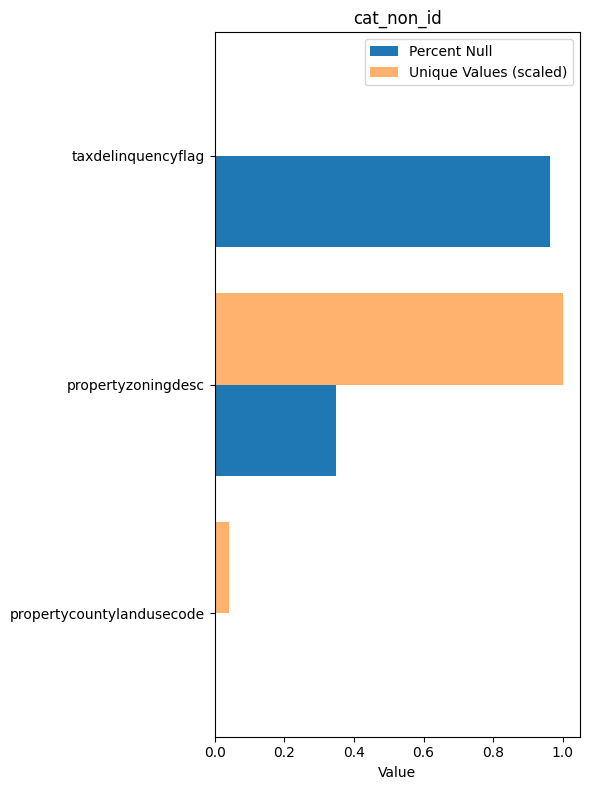

In [6]:
make_info_plot(is_string= True, potential_id= False, title='cat_non_id')

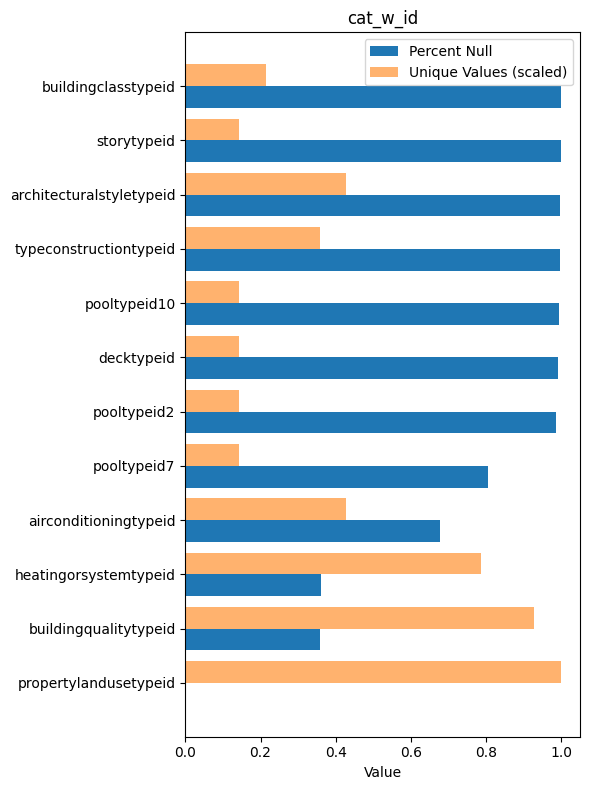

In [7]:
make_info_plot(is_string= False, potential_id= True, title= 'cat_w_id')

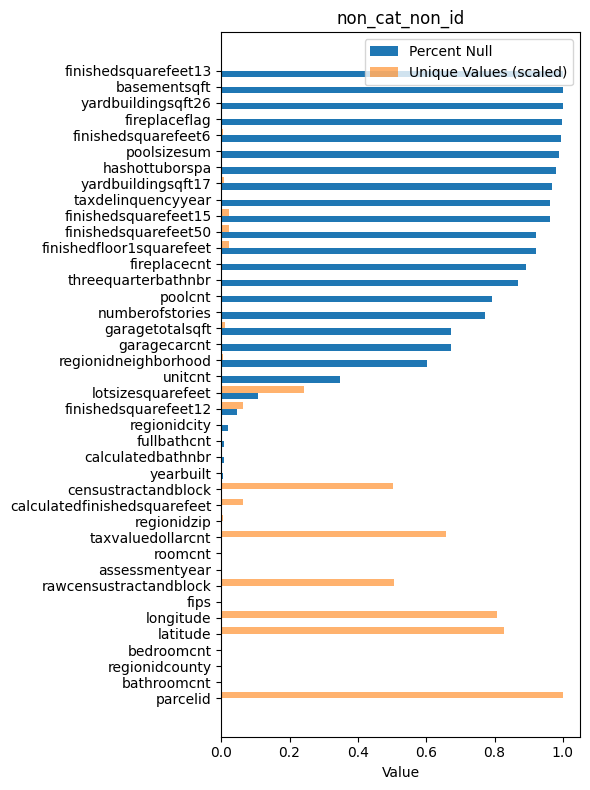

In [8]:
make_info_plot(is_string= False, potential_id= False, title= 'non_cat_non_id')

- 🔴 high null + low unique → useless
- 🟢 low null + high unique → strong signal
- ⚠️ high unique numeric → possible ID leakage

##### -- grab feature descriptors

In [9]:
def grab_feature_descriptors(column_name, top_n=10):
    s = df[column_name]
    meta = info_df.loc[info_df['column'] == column_name].copy()

    make_info_plot(is_string= False, potential_id= False, title= column_name, info_column= column_name)

    counts = df[column_name].value_counts(dropna=True).sort_index()
    counts.index = counts.index.astype(str)  # so NaN shows as "nan"

    counts.plot(kind='bar', figsize=(6, 4))
    plt.title(column_name)
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.title(f"{column_name} (not scaled)")
    plt.show()

    counts.plot(kind='bar', figsize=(6, 4), logy=True)
    plt.title(column_name)
    plt.xlabel('Value')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.title(f"{column_name} (log scaled)")
    plt.show()

    counts = df[column_name].value_counts(dropna=True).sort_index()

    # apply sqrt transform
    counts_sqrt = np.sqrt(counts)

    plt.figure(figsize=(6, 4))
    counts_sqrt.plot(kind='bar')

    plt.title(f"{column_name} (sqrt scaled)")
    plt.xlabel('Value')
    plt.ylabel('Sqrt(Count)')

    plt.tight_layout()
    plt.show()

    summary = pd.DataFrame({
        'metric': [
            'dtype', 'non_null_count', 'null_count', 'percent_null',
            'unique_values_w_null', 'is_string', 'potential_id',
            'mean', 'q1', 'median', 'q3', 'mode', 'min', 'max',
            'stdev', 'variance', 'skew', 'kurtosis'
        ],
        'value': [
            s.dtype,
            s.notna().sum(),
            s.isna().sum(),
            s.isna().mean(),
            s.nunique(dropna=False),
            meta['is_string'].iloc[0],
            meta['potential_id'].iloc[0],
            meta['mean'].iloc[0],
            meta['quantile_1'].iloc[0],
            meta['median'].iloc[0],
            meta['quantile_3'].iloc[0],
            meta['mode'].iloc[0],
            meta['min'].iloc[0],
            meta['max'].iloc[0],
            meta['stdev'].iloc[0],
            meta['variance'].iloc[0],
            meta['skew'].iloc[0],
            meta['kurtosis'].iloc[0]
        ]
    })

    sample_df = s.dropna().head(top_n).reset_index(drop=True).to_frame(name='sample_values')
    freq_df = s.value_counts(dropna=False).head(top_n).reset_index()
    freq_df.columns = ['value', 'count']

    print(f"\nFeature: {column_name}")
    display(summary)
    display(sample_df)
    display(freq_df)

    

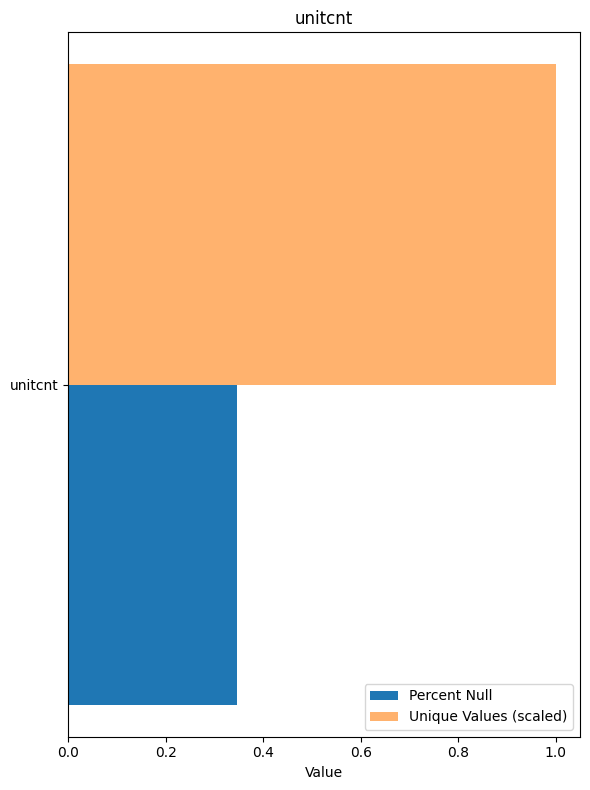

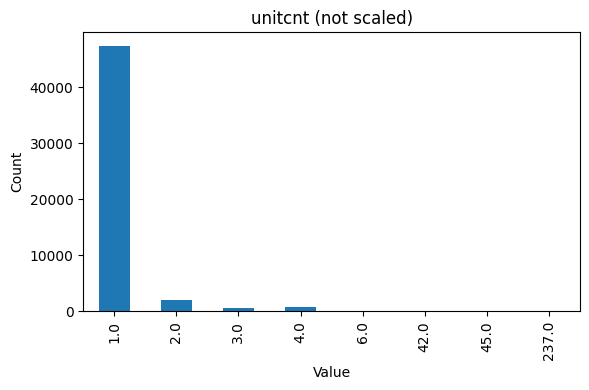

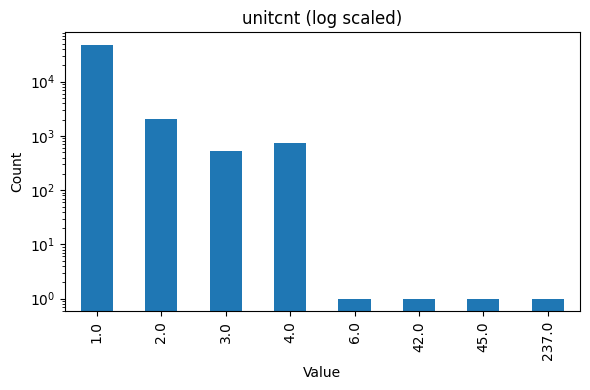

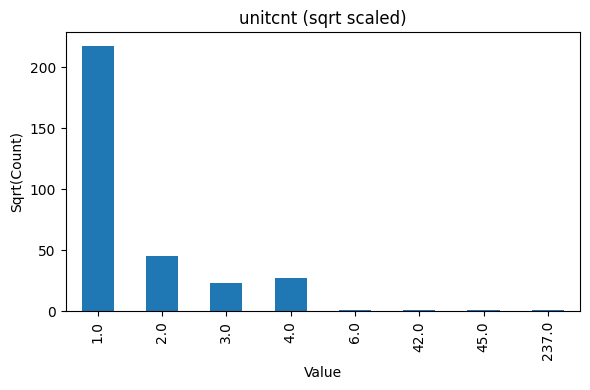


Feature: unitcnt


,metric,value
0,dtype,float64
1,non_null_count,50703
2,null_count,26910
3,percent_null,0.34672
4,unique_values_w_null,9
5,is_string,False
6,potential_id,False
7,mean,1.110309
8,q1,1.0
9,median,1.0


,sample_values
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
5,1.0
6,1.0
7,2.0
8,1.0
9,1.0


,value,count
0,1.0,47413
1,NaN,26910
2,2.0,2031
3,4.0,726
4,3.0,529
5,45.0,1
6,42.0,1
7,6.0,1
8,237.0,1


In [10]:
grab_feature_descriptors('unitcnt')

##### Andre Notes: 

>- 'cat_non_id' specifically _"taxdelinquencyflag"_ can be good for encoding
>- 'cat_w_id' can also be good for encoding; some might be better to transform into "yes" or "no" (True / False) if there is a null value present like for _"pooltypeid10"_; this feature could signify if a property has a pool which could play a big role in property value
>- 'non_cat_non_id' are columns that are very likely only __numeric__, either integers or floats; although some like _"parcelid"_, _"longitude"_, _"latitude"_, etc. may be id columns that must be removed altogether

Bonus:
>- Some variables like _"lotsizeaquareft"_ and _"finishedsquarefeet12"_ could be combined to form a new feature. For example, if finished sqft is the numerator and lot sqft is the denomiator then a new feature could be the ratio. This ratio could potential be a driver of property value since the more finished sqft the more appealing a property is to a buyer.
>- Other considerations can be made with specific features like _"regionidneighborhood"_ where these can be a sort of "segment" for different models (likely with the same framework but different hyperparameters). This could lead to better prediction accuracy overall. However, given the limited scope and time of the milestone project this could be left for a different time.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [11]:
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [13]:
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [14]:
df.nunique().sort_values (ascending = False)

parcelid                        77414
latitude                        64038
longitude                       62461
taxvaluedollarcnt               50949
rawcensustractandblock          39188
censustractandblock             39006
lotsizesquarefeet               18848
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
propertyzoningdesc               1907
finishedsquarefeet50             1807
finishedfloor1squarefeet         1787
finishedsquarefeet15             1724
garagetotalsqft                   839
yardbuildingsqft17                540
regionidneighborhood              480
regionidzip                       389
finishedsquarefeet6               350
poolsizesum                       262
regionidcity                      175
yearbuilt                         136
propertycountylandusecode          75
yardbuildingsqft26                 59
basementsqft                       43
bathroomcnt                        22
calculatedbathnbr                  21
bedroomcnt  

In [15]:
missing_percent = df.isnull().mean().sort_values(ascending = False) * 100
missing_percent [ missing_percent > 0]


buildingclasstypeid             99.980673
finishedsquarefeet13            99.945885
basementsqft                    99.935578
storytypeid                     99.935578
yardbuildingsqft26              99.909809
fireplaceflag                   99.778388
architecturalstyletypeid        99.733292
typeconstructiontypeid          99.712677
finishedsquarefeet6             99.502661
pooltypeid10                    99.400874
decktypeid                      99.208895
poolsizesum                     98.880342
pooltypeid2                     98.616211
hashottuborspa                  98.017085
yardbuildingsqft17              96.916754
taxdelinquencyyear              96.263513
taxdelinquencyflag              96.263513
finishedsquarefeet15            96.099880
finishedsquarefeet50            92.221664
finishedfloor1squarefeet        92.221664
fireplacecnt                    89.320088
threequarterbathnbr             86.978985
pooltypeid7                     80.571554
poolcnt                         79

In [16]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.values,
    "Missing %": df.isnull().mean().values * 100,
    "Unique Values": df.nunique().values
})

print (summary)


                          Column    Dtype  Missing %  Unique Values
0                       parcelid    int64   0.000000          77414
1          airconditioningtypeid  float64  67.779882              5
2       architecturalstyletypeid  float64  99.733292              5
3                   basementsqft  float64  99.935578             43
4                    bathroomcnt  float64   0.043807             22
5                     bedroomcnt  float64   0.043807             16
6            buildingclasstypeid  float64  99.980673              2
7          buildingqualitytypeid  float64  35.823895             12
8              calculatedbathnbr  float64   0.837489             21
9                     decktypeid  float64  99.208895              1
10      finishedfloor1squarefeet  float64  92.221664           1787
11  calculatedfinishedsquarefeet  float64   0.302784           4972
12          finishedsquarefeet12  float64   4.754358           4868
13          finishedsquarefeet13  float64  99.94

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

In [17]:
categorical_features = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
print("Categorical features:", categorical_features)

Categorical features: ['hashottuborspa', 'propertycountylandusecode', 'propertyzoningdesc', 'fireplaceflag', 'taxdelinquencyflag']


The categorical features are 1) hashottuborspa; 2) propertycountylandusecode 3) propertyzoningdesc 4) fireplaceflag ; 5) taxdelinquencyflag These are features that are not numerical and have labels or text in them

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

Some features may be useful for other purposes but not the business side of it. The parcel ID is very random and has no structure. The census related columns like rawcensustractandblock + censustractandblock would not be helpful. fips (Federal Information Processing Standards code, uniquely identifying counties and county equivalents) is not helpful for business. They dont give meaning for property pricing and predictions. bathroomcnt, fullbathcnt, calculatedbathnbr are all counting the number of bathrooms and are redundant.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

There are some features that have high percentage of missing values. Some features are missing 99.98%. These include buildingclasstypeid (99.980673), finishedsquarefeet13 (99.945885), storytypeid (99.935578), basementsqft (99.935578), yardbuildingsqft26 (99.909809) etc. With so many missing values, it is hard to analyze and provide importance for our purposes. However, there are some features that appear to be missing values, but just mean that they do not have a certain feature, therefore left blank. For example, fireplacecnt (89.320088) or poolcnt (79.160708) numbers are missing because those properties do not have that characteristic in the home.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

For parcelid, there are 77414 unique values differentiating the different the unique properties. Latitude and longitude have high unique values showing the coordinates, but useless in a business standpoint to analyze. rawcensustractandblock (39188) and censustractandblock (39006) are not useful too.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

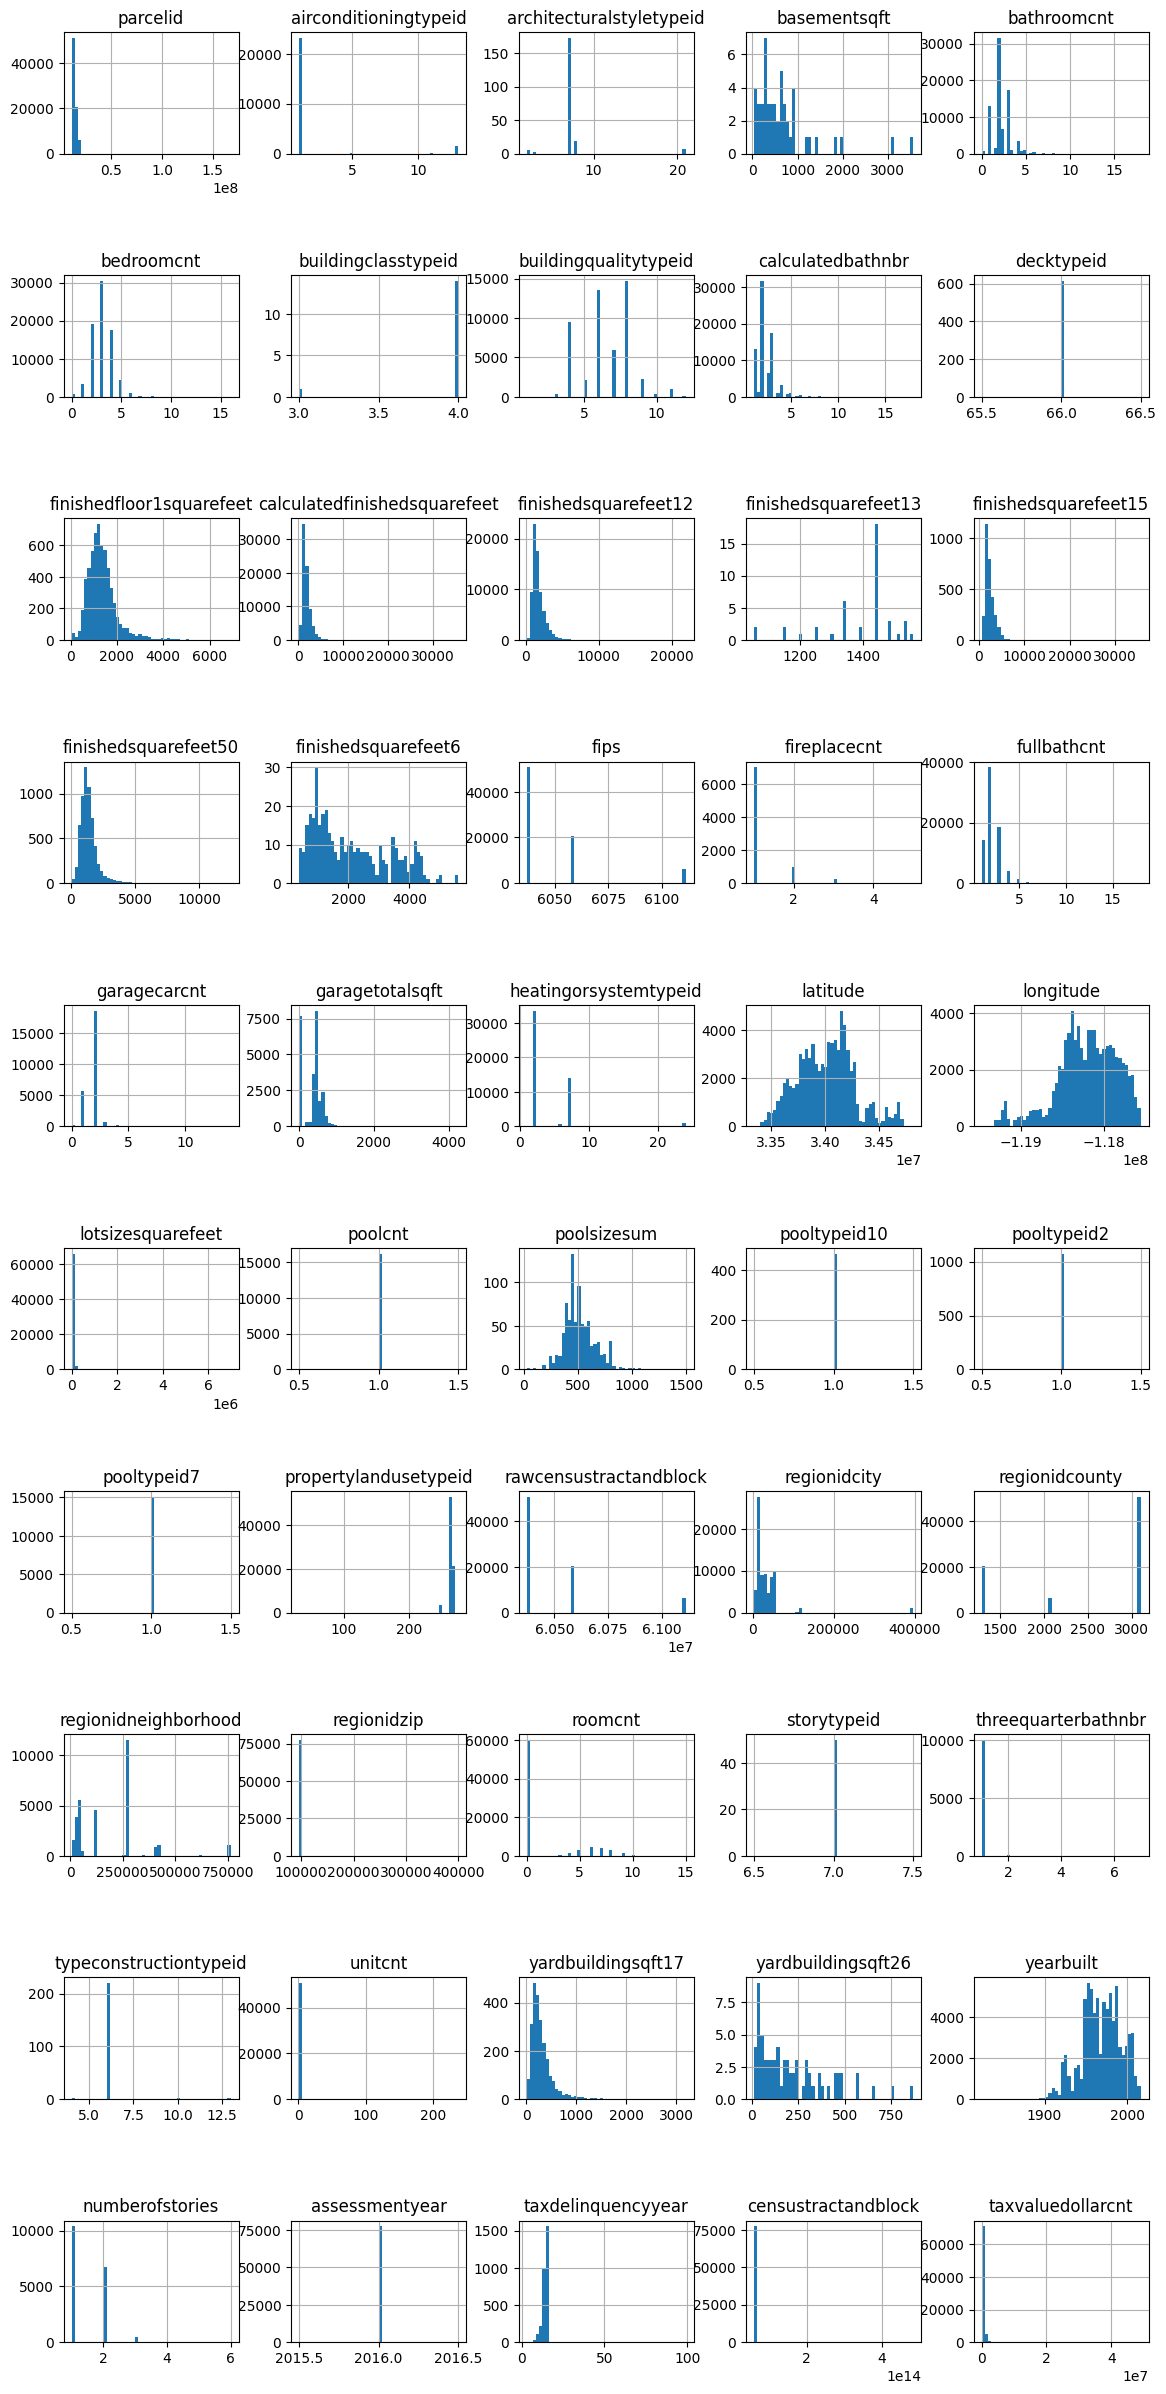

In [18]:
df.hist(figsize = (14,30), bins = 50, layout= (-1, 5)) 
plt.subplots_adjust(hspace=1.0)  # increase vertical spacing
plt.show()

Text(0, 0.5, 'Tax Value')

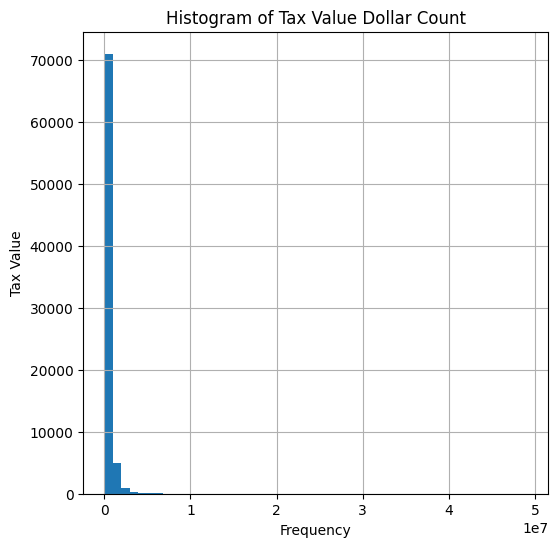

In [19]:
plt.figure (figsize = (6,6))
df['taxvaluedollarcnt'].hist(bins = 50)
plt.title ('Histogram of Tax Value Dollar Count')
plt.xlabel ('Frequency')
plt.ylabel ('Tax Value')

Text(0, 0.5, 'Tax Value')

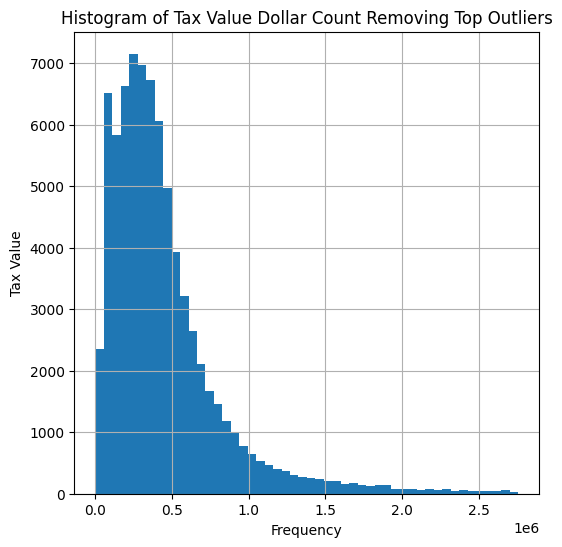

In [20]:
plt.figure (figsize = (6,6))
taxvalue = df ['taxvaluedollarcnt'].dropna()
taxvalue = taxvalue[taxvalue < taxvalue.quantile(0.99)] # drop the extreme high values of outliers
taxvalue.hist(bins = 50)
plt.title ('Histogram of Tax Value Dollar Count Removing Top Outliers')
plt.xlabel ('Frequency')
plt.ylabel ('Tax Value')

array([[<Axes: title={'center': 'calculatedfinishedsquarefeet'}>,
        <Axes: title={'center': 'finishedsquarefeet12'}>]], dtype=object)

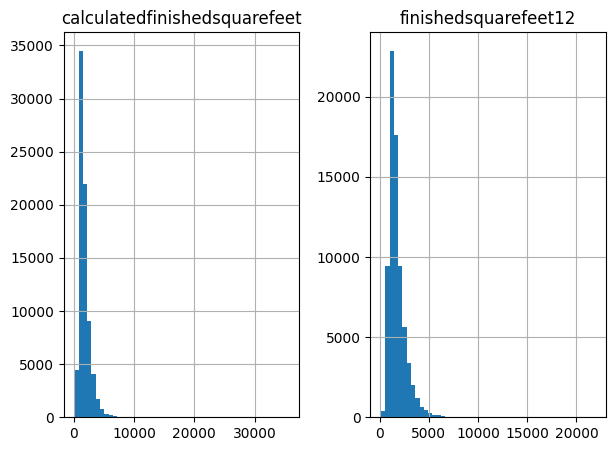

In [21]:
selected_features = ['calculatedfinishedsquarefeet', 'finishedsquarefeet12' ]
df[selected_features].hist (bins = 50, figsize = (7,5))

Mean: 1784.94
Median: 1542.00


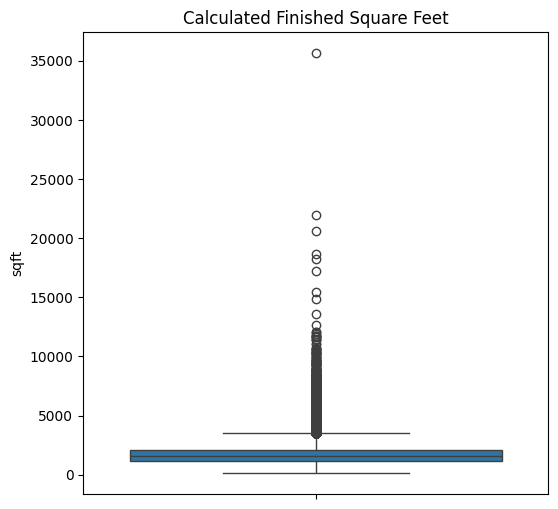

In [22]:
plt.figure(figsize = (6,6))

sns.boxplot(df['calculatedfinishedsquarefeet'])
plt.title('Calculated Finished Square Feet')
plt.ylabel('sqft')

print(f"Mean: {df['calculatedfinishedsquarefeet'].mean():.2f}")
print(f"Median: {df['calculatedfinishedsquarefeet'].median():.2f}")

Mean: 1760.28
Median: 1523.00


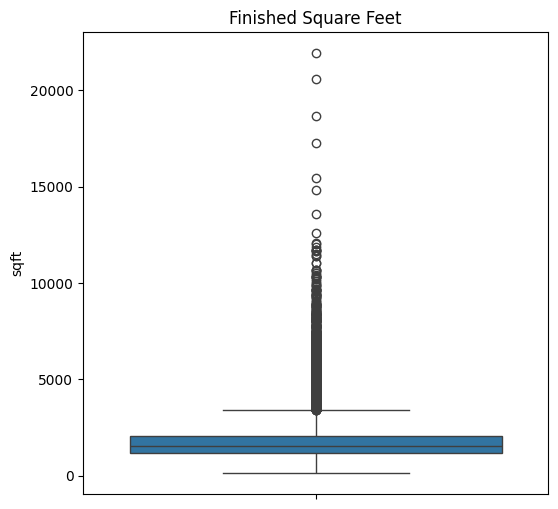

In [23]:
plt.figure(figsize = (6,6))

sns.boxplot(df['finishedsquarefeet12'])
plt.title('Finished Square Feet')
plt.ylabel('sqft')

print(f"Mean: {df['finishedsquarefeet12'].mean():.2f}")
print(f"Median: {df['finishedsquarefeet12'].median():.2f}")

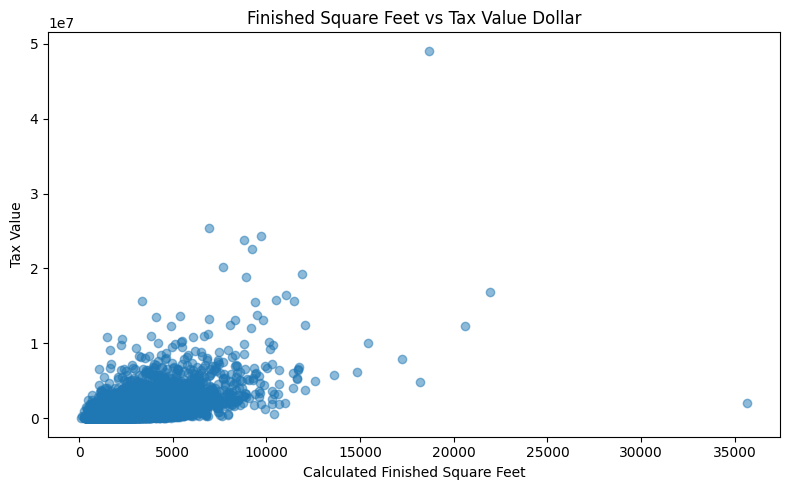

In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['calculatedfinishedsquarefeet'], 
    df['taxvaluedollarcnt'], 
    alpha=0.5
)
#plt.yscale('log') #equal spacing and reduce the skew
plt.title('Finished Square Feet vs Tax Value Dollar')
plt.xlabel('Calculated Finished Square Feet')
plt.ylabel('Tax Value')
plt.tight_layout()
plt.show()

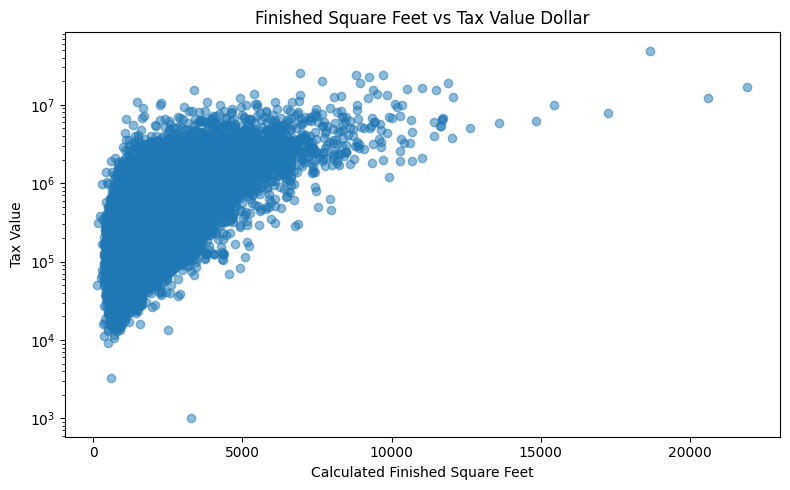

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['finishedsquarefeet12'], 
    df['taxvaluedollarcnt'], 
    alpha=0.5
)
plt.yscale('log') #equal spacing and reduce the skew
plt.title('Finished Square Feet vs Tax Value Dollar')
plt.xlabel('Calculated Finished Square Feet')
plt.ylabel('Tax Value')
plt.tight_layout()
plt.show()

Mean: 1968.61
Median: 1970.00


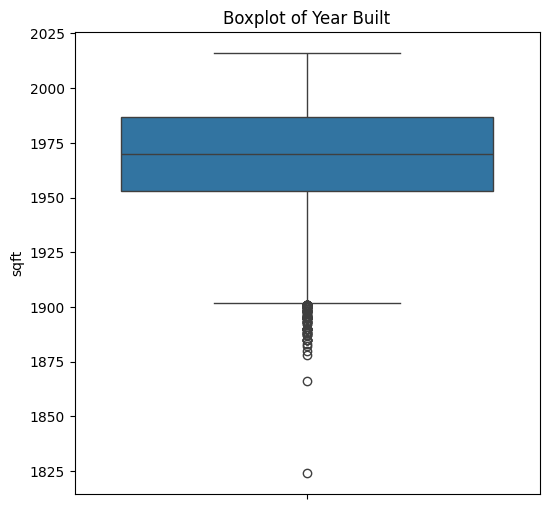

In [26]:
plt.figure(figsize = (6,6))

sns.boxplot(df['yearbuilt'])
plt.title('Boxplot of Year Built')
plt.ylabel('sqft')



print(f"Mean: {df['yearbuilt'].mean():.2f}")
print(f"Median: {df['yearbuilt'].median():.2f}")

Text(0, 0.5, 'Frequency')

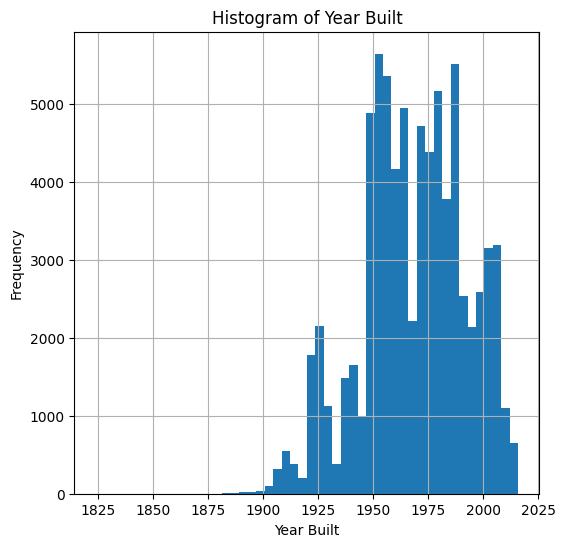

In [27]:
plt.figure (figsize = (6,6))
df['yearbuilt'].hist(bins = 50)
plt.title ('Histogram of Year Built')
plt.xlabel ('Year Built')
plt.ylabel ('Frequency')

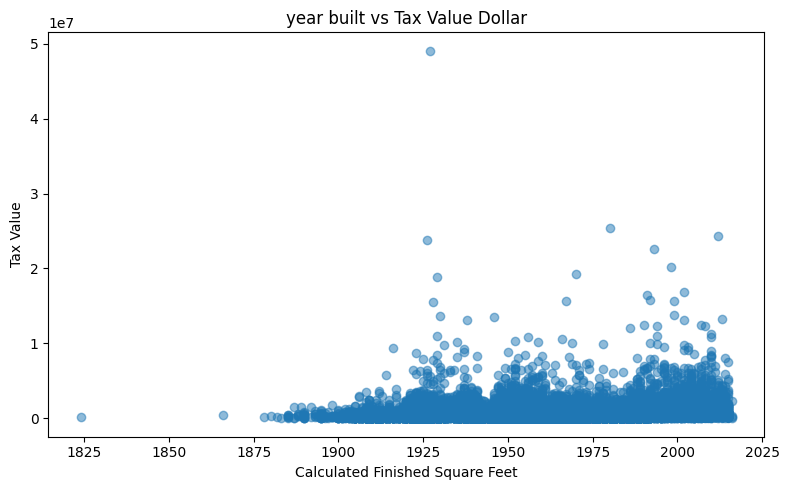

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['yearbuilt'], 
    df['taxvaluedollarcnt'], 
    alpha=0.5
)

plt.title('year built vs Tax Value Dollar')
plt.xlabel('Calculated Finished Square Feet')
plt.ylabel('Tax Value')
plt.tight_layout()
plt.show()

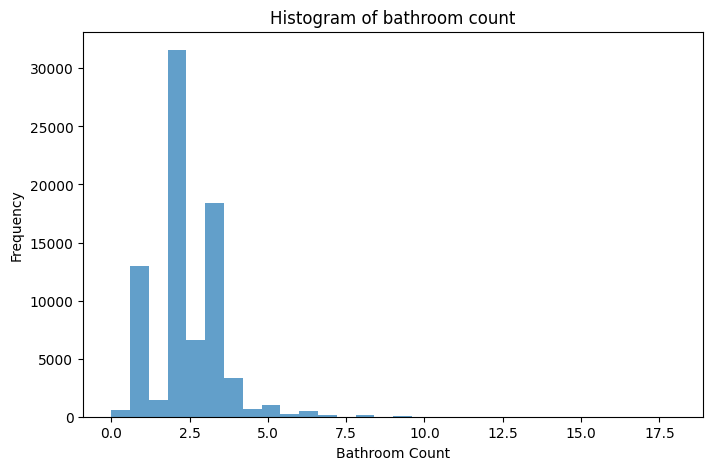

Mean: 2.30
Median: 2.00


In [29]:
plt.figure(figsize=(8, 5))
plt.hist(df['bathroomcnt'].dropna(), bins=30, alpha=0.7)  # Drop NaN for histogram
plt.title('Histogram of bathroom count')
plt.xlabel('Bathroom Count')
plt.ylabel("Frequency")
plt.show()
print(f"Mean: {df['bathroomcnt'].mean():.2f}")
print(f"Median: {df['bathroomcnt'].median():.2f}")

Mean: 2.30
Median: 2.00


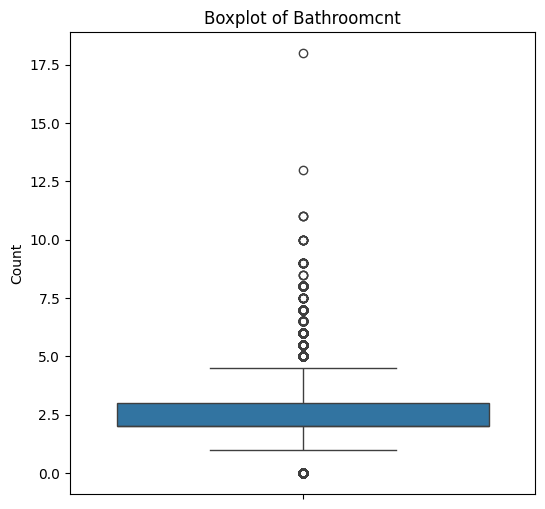

In [30]:
plt.figure(figsize = (6,6))

sns.boxplot(df['bathroomcnt'])
plt.title('Boxplot of Bathroomcnt')
plt.ylabel('Count')

print(f"Mean: {df['bathroomcnt'].mean():.2f}")
print(f"Median: {df['bathroomcnt'].median():.2f}")

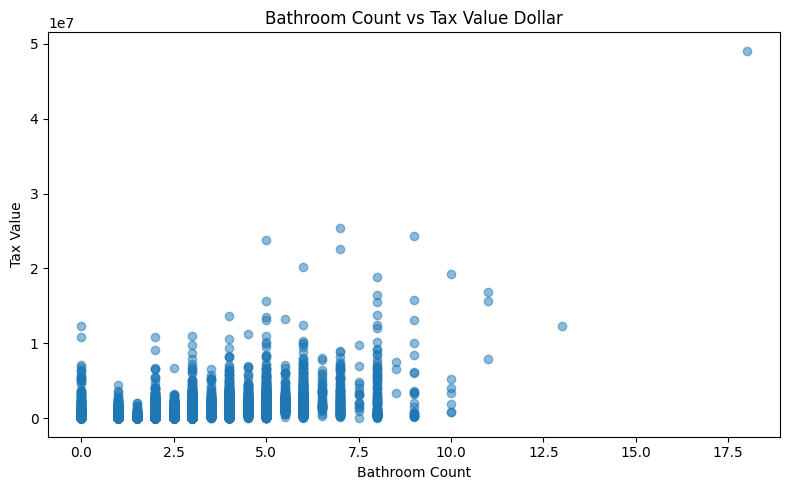

In [31]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['bathroomcnt'], 
    df['taxvaluedollarcnt'], 
    alpha=0.5
)

plt.title('Bathroom Count vs Tax Value Dollar')
plt.xlabel('Bathroom Count')
plt.ylabel('Tax Value')
plt.tight_layout()
plt.show()

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


I analyzed the different features of Year Built, Finished Square Feet, and Bathroom Count against the target value of Tax Value Dollar Count. 

For YearBuilt: the distribution was a left skewed distribution with a mean of 1968.61 and median: 1970.00. In the boxplot it shows that there are several outiers of properties built before 1900. When plotted with Tax Value, I would expect the tax value of an older property to be higher, but the distribution of my scatterplot was pretty uniform. 

For Finished Square Feet, the distribution was right skewed. I compared the calculatedfinishedsquarefeet and finishedsquarefeet12 which both showed the finished living area. There are not much differences between the two. The mean and median of both are pretty similar and also the outliers lie with a wide range over 5000 square foot. I believe the finished square feet play a key role in determining the tax value dollar. 

Last feature I looked at was Bathroom count. The bathroom count has a pretty normal distribution with a couple of prominent peaks. It could be viewed as right skewed The mean is 2.30 and median is 2.00. There were no odd characteristics for the most part and have some understandable outliers with homes with more than 5 bathrooms. When plotted with Tax Dollar, the scatter plot seemed to have no apparent trend. I wanted to see if the bathrooms affected the tax value. 

When looking at Tax Value dollar by itself, it was a right skewed distribution. The features are all physical aspects that contribute to the tax value dollar and I wanted to explore that relationship. There were not a lot of missing values making the examination easy to explore. 

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [32]:
df_dropped = df.drop (columns =['parcelid', 'calculatedbathnbr', 'fullbathcnt', 'rawcensustractandblock', 'censustractandblock' , 'latitude', 'longitude', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7'])

df_dropped.shape[1]

45

#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [33]:
def show_null_counts_features(df):
    
    count_nulls = df.isnull().sum()
    df_nulls = (df.isnull().mean() * 100).round(2)

    
    feature_types = df.dtypes.apply(
        lambda x: "Numeric" if np.issubdtype(x, np.number) else "Categorical"
    )

    
    missing_data = pd.DataFrame({
        "Feature": count_nulls[count_nulls > 0].index,
        "# Null Values": count_nulls[count_nulls > 0].values,
        "Null %": df_nulls[count_nulls > 0].values,          
        "Type": feature_types[count_nulls > 0].values
    }).sort_values(by="Null %", ascending=False)

    print(f"\nThe dataset contains {len(df):,} samples.\n")

    if len(missing_data) == 0:
        print("There are no null values in the dataset!")
        return

    
    pd.set_option("display.max_rows", None)
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 200)
    pd.set_option("display.max_colwidth", None)

    
    missing_data = missing_data.reset_index(drop=True)
    missing_data["Null %"] = missing_data["Null %"].map(lambda x: f"{x:.2f}%")

    print(missing_data.to_string(index=False))

df = df_dropped.copy()
show_null_counts_features(df)



The dataset contains 77,613 samples.

                     Feature  # Null Values Null %        Type
         buildingclasstypeid          77598 99.98%     Numeric
        finishedsquarefeet13          77571 99.95%     Numeric
                basementsqft          77563 99.94%     Numeric
                 storytypeid          77563 99.94%     Numeric
          yardbuildingsqft26          77543 99.91%     Numeric
               fireplaceflag          77441 99.78% Categorical
    architecturalstyletypeid          77406 99.73%     Numeric
      typeconstructiontypeid          77390 99.71%     Numeric
         finishedsquarefeet6          77227 99.50%     Numeric
                  decktypeid          76999 99.21%     Numeric
                 poolsizesum          76744 98.88%     Numeric
              hashottuborspa          76074 98.02% Categorical
          yardbuildingsqft17          75220 96.92%     Numeric
          taxdelinquencyyear          74713 96.26%     Numeric
          taxdel

**From the table above, columns with 96%–99% missing values are likely too sparse to be useful. The limited number of observed values makes imputation unreliable, as techniques like mean or frequency-based filling would not capture the true distribution and could introduce significant bias.**

In [34]:
def drop_high_null_columns(df, threshold=96):
    null_percent = (df.isnull().mean() * 100).round(2)
    cols_to_drop = null_percent[null_percent > threshold]

    dropped_df = cols_to_drop.reset_index()
    dropped_df.columns = ["Feature", "Null %"]

    df_cleaned = df.drop(columns=cols_to_drop.index)

    return df_cleaned, dropped_df

In [35]:
df_cleaned, dropped_info = drop_high_null_columns(df)
print(dropped_info)

                     Feature  Null %
0   architecturalstyletypeid   99.73
1               basementsqft   99.94
2        buildingclasstypeid   99.98
3                 decktypeid   99.21
4       finishedsquarefeet13   99.95
5       finishedsquarefeet15   96.10
6        finishedsquarefeet6   99.50
7             hashottuborspa   98.02
8                poolsizesum   98.88
9                storytypeid   99.94
10    typeconstructiontypeid   99.71
11        yardbuildingsqft17   96.92
12        yardbuildingsqft26   99.91
13             fireplaceflag   99.78
14        taxdelinquencyflag   96.26
15        taxdelinquencyyear   96.26


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



**Features with more than 96% missing values were dropped from the dataset. This threshold was chosen because columns with such a high proportion of null values contain very little usable information, making them unreliable for analysis. In many cases, only 1–4% of the data was actually observed, which is insufficient to capture meaningful patterns. Although imputation methods such as mean or frequency-based filling could be applied, they would rely on too few real observations and would likely introduce bias or unrealistic values. The specific features removed, along with their null percentages, are shown in the output above. Removing these columns improves the overall data quality and ensures that subsequent analysis is based on more complete and reliable features.**

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [36]:
df_cleaned = df_cleaned.dropna(subset=['taxvaluedollarcnt']) #dropping columns with null values in target variable

In [37]:
cols = ["finishedfloor1squarefeet","calculatedfinishedsquarefeet",
        "finishedsquarefeet12","lotsizesquarefeet","garagetotalsqft"]

df_cleaned[cols].describe(percentiles=[.95,.99,.995,.999]).T

,count,mean,std,min,50%,95%,99%,99.5%,99.9%,max
finishedfloor1squarefeet,6037.0,1366.165314,670.701336,44.0,1257.0,2538.00,4003.20,4476.64,5934.272,6912.0
calculatedfinishedsquarefeet,77377.0,1784.943019,954.254198,128.0,1542.0,3540.00,5125.44,6000.36,8609.624,35640.0
finishedsquarefeet12,73922.0,1760.292173,934.356589,128.0,1523.0,3464.00,5115.79,6020.00,8610.395,21929.0
lotsizesquarefeet,69320.0,29973.765392,123305.907773,236.0,7206.0,128022.65,465072.00,598159.00,1135839.000,6971010.0
garagetotalsqft,25519.0,350.050433,261.650643,0.0,436.0,687.00,919.64,1052.05,1525.086,4251.0


In [38]:
cutoffs_999 = df_cleaned[cols].quantile(0.999)

# rows that exceed ANY cutoff
outlier_rows = (df_cleaned[cols] > cutoffs_999).any(axis=1)

print("99.9% cutoffs:\n", cutoffs_999)
print("\nRows flagged:", outlier_rows.sum())

99.9% cutoffs:
 finishedfloor1squarefeet           5934.272
calculatedfinishedsquarefeet       8609.624
finishedsquarefeet12               8610.395
lotsizesquarefeet               1135839.000
garagetotalsqft                    1525.086
Name: 0.999, dtype: float64

Rows flagged: 174


In [39]:
df_cleaned = df_cleaned.loc[~outlier_rows].copy()

#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


After dropping features with extreme missingness, I evaluated the remaining dataset at the **sample (row) level** by looking at **feature distributions** for continuous variables (especially square footage and lot size fields). Several variables showed strong right-skew with a small number of extreme values. To prevent these rare extremes from disproportionately influencing summary statistics and any downstream modeling, I flagged rows using a percentile-based outlier rule.

Specifically, I computed the **99.9th percentile cutoff** for key continuous “size” features (e.g., `finishedfloor1squarefeet`, `calculatedfinishedsquarefeet`, `finishedsquarefeet12`, `lotsizesquarefeet`, and `garagetotalsqft`). Any row that exceeded the 99.9th percentile in **at least one** of these variables was treated as an outlier and removed. This approach is conservative (it targets only the most extreme ~0.1% of values per feature) and aligns with what was visible in the distribution plots, where a small number of observations formed a long tail far beyond the bulk of the data. As a result, the remaining dataset better represents typical properties and reduces the risk that a handful of extreme samples dominate the analysis.


### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [40]:
categorical_features = df_cleaned.select_dtypes(exclude=["number"]).columns.tolist()
numeric_features = [
    c for c in df_cleaned.select_dtypes(include=["number"]).columns
    if c not in ["taxvaluedollarcnt"]  
]

Dropping rows where target is NAN

In [41]:
df_cleaned.head(10)

,airconditioningtypeid,bathroomcnt,bedroomcnt,buildingqualitytypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet50,fips,fireplacecnt,garagecarcnt,garagetotalsqft,heatingorsystemtypeid,lotsizesquarefeet,poolcnt,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,threequarterbathnbr,unitcnt,yearbuilt,numberofstories,assessmentyear,taxvaluedollarcnt
0,NaN,3.5,4.0,NaN,NaN,3100.0,3100.0,NaN,6059.0,NaN,2.0,633.0,NaN,4506.0,NaN,122,261.0,NaN,53571.0,1286.0,NaN,96978.0,0.0,1.0,NaN,1998.0,NaN,2016.0,1023282.0
1,NaN,1.0,2.0,NaN,1465.0,1465.0,1465.0,1465.0,6111.0,1.0,1.0,0.0,NaN,12647.0,NaN,1110,261.0,NaN,13091.0,2061.0,NaN,97099.0,5.0,NaN,NaN,1967.0,1.0,2016.0,464000.0
2,NaN,2.0,3.0,NaN,NaN,1243.0,1243.0,NaN,6059.0,NaN,2.0,440.0,NaN,8432.0,1.0,122,261.0,NaN,21412.0,1286.0,NaN,97078.0,6.0,NaN,NaN,1962.0,1.0,2016.0,564778.0
3,NaN,3.0,4.0,8.0,NaN,2376.0,2376.0,NaN,6037.0,NaN,NaN,NaN,2.0,13038.0,1.0,0101,261.0,LCR110000*,396551.0,3101.0,NaN,96330.0,0.0,NaN,1.0,1970.0,NaN,2016.0,145143.0
4,1.0,3.0,3.0,8.0,NaN,1312.0,1312.0,NaN,6037.0,NaN,NaN,NaN,2.0,278581.0,1.0,010C,266.0,LAR3,12447.0,3101.0,268548.0,96451.0,0.0,NaN,1.0,1964.0,NaN,2016.0,119407.0
5,NaN,2.0,3.0,NaN,842.0,1492.0,1492.0,842.0,6111.0,1.0,2.0,0.0,NaN,903.0,NaN,1129,266.0,NaN,51239.0,2061.0,NaN,97091.0,6.0,NaN,NaN,1982.0,2.0,2016.0,331064.0
6,1.0,3.0,4.0,9.0,NaN,2962.0,2962.0,NaN,6037.0,NaN,NaN,NaN,2.0,63000.0,1.0,0101,261.0,PSR2,47019.0,3101.0,274684.0,96293.0,0.0,NaN,1.0,1950.0,NaN,2016.0,773303.0
7,NaN,1.0,2.0,5.0,NaN,738.0,738.0,NaN,6037.0,NaN,NaN,NaN,NaN,4214.0,NaN,0100,261.0,GLR4YY,45457.0,3101.0,276258.0,96325.0,0.0,NaN,1.0,1922.0,NaN,2016.0,218552.0
8,NaN,3.0,4.0,9.0,NaN,3039.0,3039.0,NaN,6037.0,NaN,NaN,NaN,2.0,20028.0,NaN,0100,261.0,WHRE20000*,14634.0,3101.0,NaN,96173.0,0.0,NaN,1.0,1970.0,NaN,2016.0,220583.0
9,NaN,3.0,2.0,8.0,NaN,1290.0,1290.0,NaN,6037.0,NaN,NaN,NaN,2.0,54048.0,1.0,010C,266.0,LAR3,12447.0,3101.0,403184.0,96047.0,0.0,NaN,1.0,1980.0,NaN,2016.0,371361.0


In [42]:
typeid_cols = [c for c in df_cleaned.columns if c.endswith("typeid")]
region_cols = [c for c in df_cleaned.columns if c.startswith("regionid")]
code_like = typeid_cols + region_cols + ["fips", "propertylandusetypeid"]

# treat these as categorical for imputation purposes
cat_cols = df_cleaned.select_dtypes(include=["object"]).columns.tolist()
cat_cols = sorted(set(cat_cols + [c for c in code_like if c in df_cleaned.columns]))

# numeric measurement columns = numeric minus code-like minus id
num_cols = df_cleaned.select_dtypes(include=["number"]).columns.tolist()
num_cols = [c for c in num_cols if c not in cat_cols]

In [43]:
print(cat_cols)

['airconditioningtypeid', 'buildingqualitytypeid', 'fips', 'heatingorsystemtypeid', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip']


In [44]:
# Impute numeric with median, categorical with most frequent

df_imputed = df_cleaned.copy()

num_imputer = SimpleImputer(strategy="median")
df_imputed[numeric_features] = num_imputer.fit_transform(df_imputed[numeric_features])

cat_imputer = SimpleImputer(strategy="most_frequent")
df_imputed[categorical_features] = cat_imputer.fit_transform(df_imputed[categorical_features])


print(f"Final cleaned dataset: {df_imputed.shape[0]:,} rows x {df_imputed.shape[1]} columns")
show_null_counts_features(df_imputed)

Final cleaned dataset: 77,404 rows x 29 columns

The dataset contains 77,404 samples.

There are no null values in the dataset!


In [45]:
df_imputed.head(10)

,airconditioningtypeid,bathroomcnt,bedroomcnt,buildingqualitytypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet50,fips,fireplacecnt,garagecarcnt,garagetotalsqft,heatingorsystemtypeid,lotsizesquarefeet,poolcnt,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,threequarterbathnbr,unitcnt,yearbuilt,numberofstories,assessmentyear,taxvaluedollarcnt
0,1.0,3.5,4.0,6.0,1254.5,3100.0,3100.0,1257.0,6059.0,1.0,2.0,633.0,2.0,4506.0,1.0,122,261.0,LAR1,53571.0,1286.0,118849.0,96978.0,0.0,1.0,1.0,1998.0,1.0,2016.0,1023282.0
1,1.0,1.0,2.0,6.0,1465.0,1465.0,1465.0,1465.0,6111.0,1.0,1.0,0.0,2.0,12647.0,1.0,1110,261.0,LAR1,13091.0,2061.0,118849.0,97099.0,5.0,1.0,1.0,1967.0,1.0,2016.0,464000.0
2,1.0,2.0,3.0,6.0,1254.5,1243.0,1243.0,1257.0,6059.0,1.0,2.0,440.0,2.0,8432.0,1.0,122,261.0,LAR1,21412.0,1286.0,118849.0,97078.0,6.0,1.0,1.0,1962.0,1.0,2016.0,564778.0
3,1.0,3.0,4.0,8.0,1254.5,2376.0,2376.0,1257.0,6037.0,1.0,2.0,436.0,2.0,13038.0,1.0,0101,261.0,LCR110000*,396551.0,3101.0,118849.0,96330.0,0.0,1.0,1.0,1970.0,1.0,2016.0,145143.0
4,1.0,3.0,3.0,8.0,1254.5,1312.0,1312.0,1257.0,6037.0,1.0,2.0,436.0,2.0,278581.0,1.0,010C,266.0,LAR3,12447.0,3101.0,268548.0,96451.0,0.0,1.0,1.0,1964.0,1.0,2016.0,119407.0
5,1.0,2.0,3.0,6.0,842.0,1492.0,1492.0,842.0,6111.0,1.0,2.0,0.0,2.0,903.0,1.0,1129,266.0,LAR1,51239.0,2061.0,118849.0,97091.0,6.0,1.0,1.0,1982.0,2.0,2016.0,331064.0
6,1.0,3.0,4.0,9.0,1254.5,2962.0,2962.0,1257.0,6037.0,1.0,2.0,436.0,2.0,63000.0,1.0,0101,261.0,PSR2,47019.0,3101.0,274684.0,96293.0,0.0,1.0,1.0,1950.0,1.0,2016.0,773303.0
7,1.0,1.0,2.0,5.0,1254.5,738.0,738.0,1257.0,6037.0,1.0,2.0,436.0,2.0,4214.0,1.0,0100,261.0,GLR4YY,45457.0,3101.0,276258.0,96325.0,0.0,1.0,1.0,1922.0,1.0,2016.0,218552.0
8,1.0,3.0,4.0,9.0,1254.5,3039.0,3039.0,1257.0,6037.0,1.0,2.0,436.0,2.0,20028.0,1.0,0100,261.0,WHRE20000*,14634.0,3101.0,118849.0,96173.0,0.0,1.0,1.0,1970.0,1.0,2016.0,220583.0
9,1.0,3.0,2.0,8.0,1254.5,1290.0,1290.0,1257.0,6037.0,1.0,2.0,436.0,2.0,54048.0,1.0,010C,266.0,LAR3,12447.0,3101.0,403184.0,96047.0,0.0,1.0,1.0,1980.0,1.0,2016.0,371361.0


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


**First we decided which columns should be treated as categories and which ones are true numeric measurements. Some columns are stored as numbers but they actually represent labels or codes rather than measurable amounts, such as columns ending in `typeid` and location code columns like `regionidzip` and `fips`, and we also treated text fields like `propertycountylandusecode` and `propertyzoningdesc` as categorical.  After separating columns this way, we filled in missing values using a simple rule that matches what the data means: for real numeric measurement columns like square footage, bedroom and bathroom counts, year built, and tax value, we used the median because these variables are often skewed and the median is less influenced by extreme values, while for categorical columns including numeric coded categories and text categories, we used the most common value because it replaces missing entries with the category that appears most often and avoids inserting a “middle” code that does not have a meaningful interpretation.**

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [46]:
cat_cols = df_imputed.select_dtypes(include=["object", "category"]).columns.tolist()
print("Encoding columns:", cat_cols)

df_encoded = df_imputed.copy()

encoder = OrdinalEncoder()
df_encoded[cat_cols] = encoder.fit_transform(df_encoded[cat_cols])

print(f"\nShape before: {df_imputed.shape}")
print(f"Shape after:  {df_encoded.shape}")
print("\nSample of encoded columns:")
print(df_encoded[cat_cols].head())

Encoding columns: ['propertycountylandusecode', 'propertyzoningdesc']

Shape before: (77404, 29)
Shape after:  (77404, 29)

Sample of encoded columns:
   propertycountylandusecode  propertyzoningdesc
0                       60.0               578.0
1                       51.0               578.0
2                       60.0               578.0
3                        1.0               794.0
4                        8.0               585.0


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

In [47]:
# Drop zero-variance columns — correlation is undefined for them (std = 0) and they carry no predictive information since every value is the same

zero_var_cols = [col for col in df_imputed.select_dtypes(include='number').columns
                 if df_imputed[col].nunique() == 1]

print("Zero variance columns dropped:", zero_var_cols)
df_imputed = df_imputed.drop(columns=zero_var_cols)

Zero variance columns dropped: ['poolcnt', 'assessmentyear']


In [48]:
numeric_cols = df_imputed.select_dtypes(include='number').columns.tolist()

target_corr = (
    df_imputed[numeric_cols]
    .corr()['taxvaluedollarcnt']
    .drop('taxvaluedollarcnt')
    .sort_values()
)

print("Top 10 positively correlated:")
print(target_corr.tail(10))
print("\nTop 10 negatively correlated:")
print(target_corr.head(10))

Top 10 positively correlated:
finishedfloor1squarefeet        0.089008
fireplacecnt                    0.102164
yearbuilt                       0.131010
garagecarcnt                    0.138442
garagetotalsqft                 0.148882
bedroomcnt                      0.232437
buildingqualitytypeid           0.257238
bathroomcnt                     0.455454
calculatedfinishedsquarefeet    0.564204
finishedsquarefeet12            0.574292
Name: taxvaluedollarcnt, dtype: float64

Top 10 negatively correlated:
heatingorsystemtypeid   -0.113317
regionidcounty          -0.051124
propertylandusetypeid   -0.034708
lotsizesquarefeet       -0.029966
regionidcity            -0.023603
roomcnt                  0.004637
airconditioningtypeid    0.004746
unitcnt                  0.005008
fips                     0.009855
regionidzip              0.018178
Name: taxvaluedollarcnt, dtype: float64


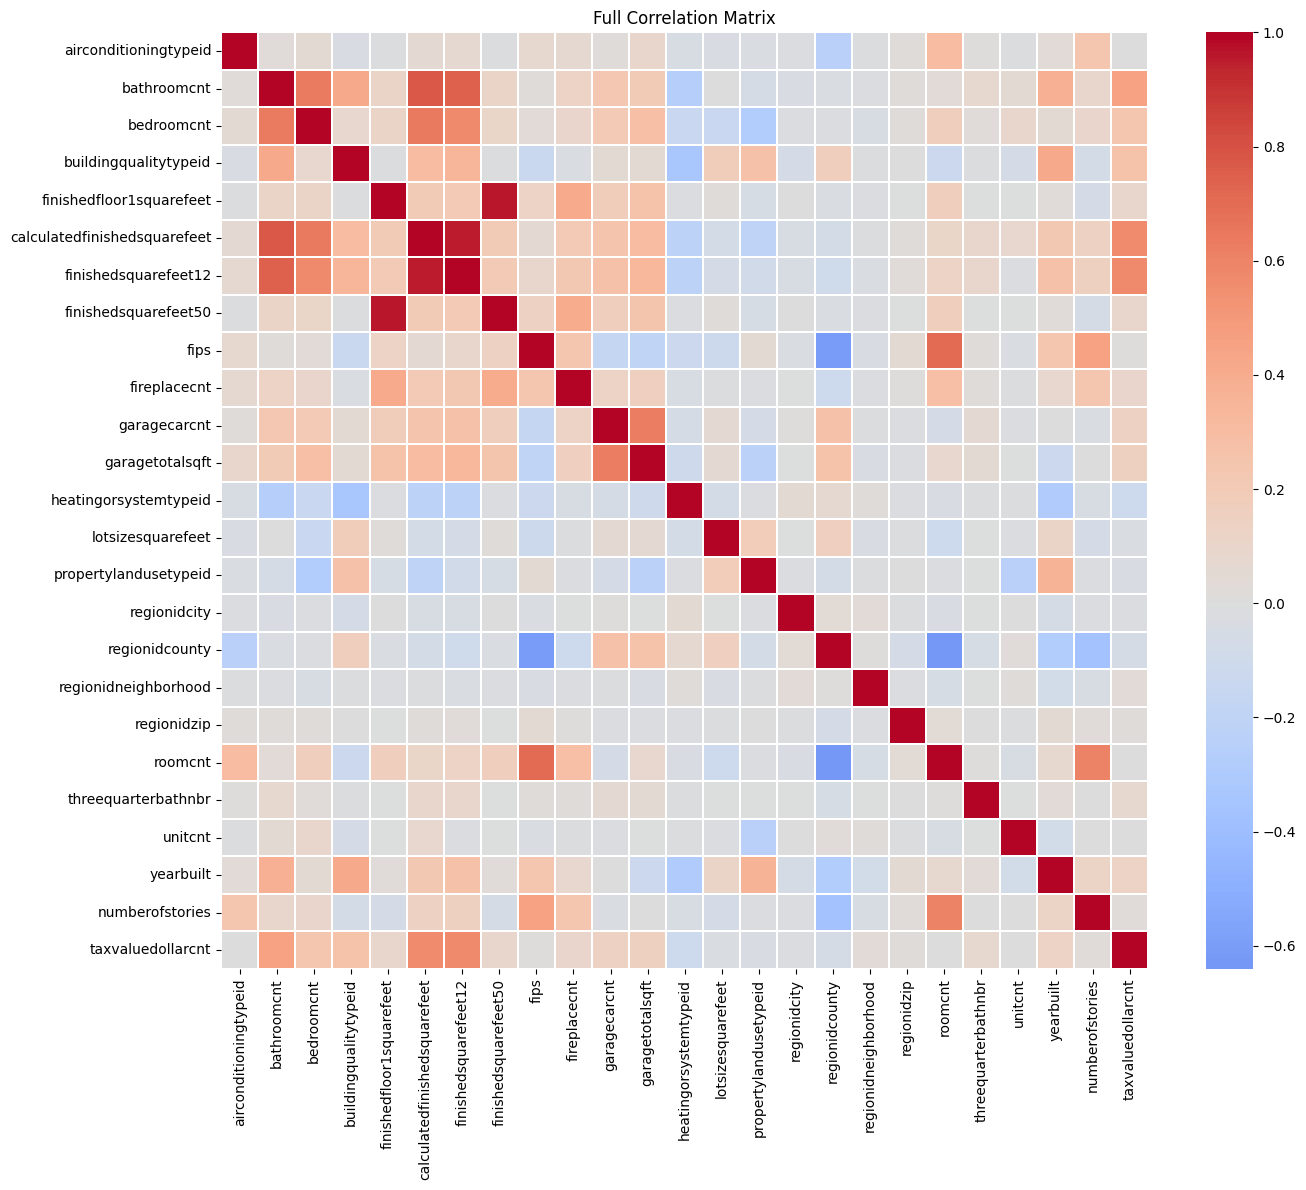

In [49]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    df_imputed[numeric_cols].corr(),
    cmap='coolwarm', center=0,
    linewidths=0.3
)
plt.title('Full Correlation Matrix')
plt.tight_layout()
plt.show()

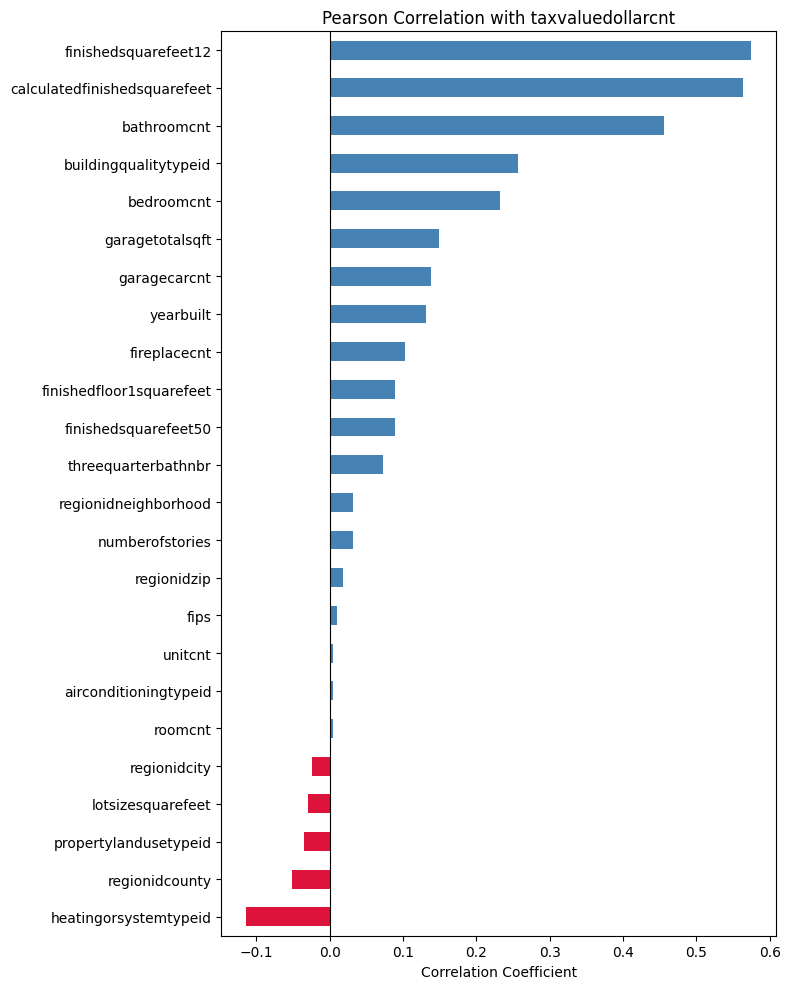

In [50]:
plt.figure(figsize=(8, 10))
colors = ['crimson' if v < 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', color=colors)
plt.title('Pearson Correlation with taxvaluedollarcnt')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

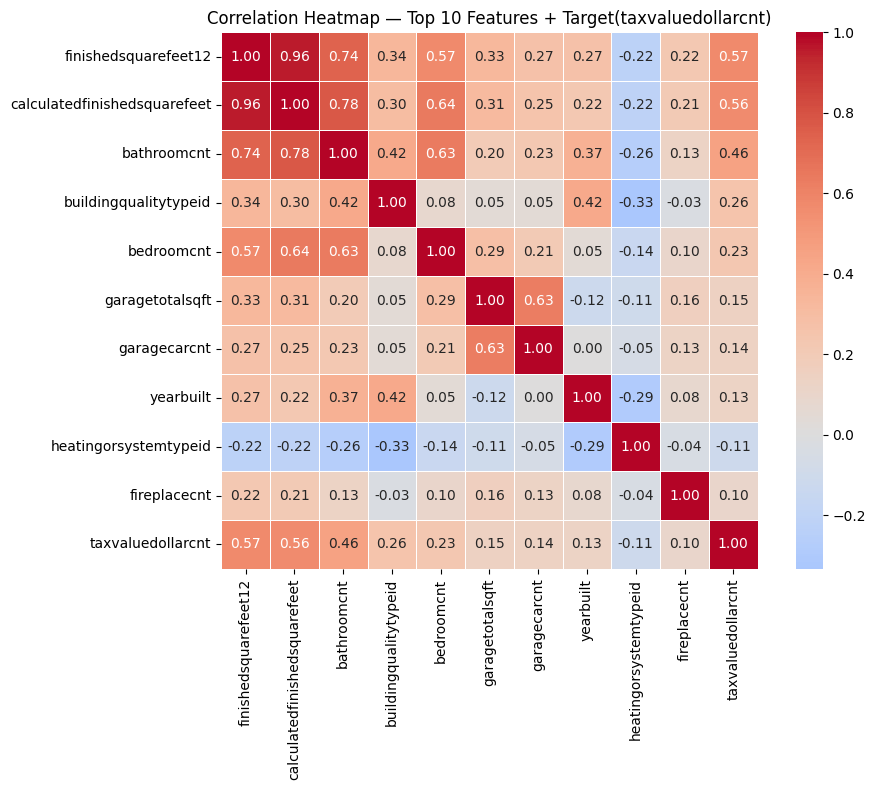

In [51]:
top_features = target_corr.abs().nlargest(10).index.tolist() + ['taxvaluedollarcnt']

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_imputed[top_features].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap — Top 10 Features + Target(taxvaluedollarcnt)')
plt.tight_layout()
plt.show()

In [52]:
df_fstat = df_imputed[numeric_cols]
X_f = df_fstat.drop(columns='taxvaluedollarcnt')
y_f = df_fstat['taxvaluedollarcnt']

f_stats, p_vals = f_regression(X_f, y_f)

fstat_df = pd.DataFrame({
    'feature': X_f.columns,
    'f_stat': f_stats,
    'p_value': p_vals
}).sort_values('f_stat', ascending=False)

print("Top 10 features by F-statistic:")
print(fstat_df.head(10).to_string(index=False))

Top 10 features by F-statistic:
                     feature       f_stat       p_value
        finishedsquarefeet12 38090.855209  0.000000e+00
calculatedfinishedsquarefeet 36145.008226  0.000000e+00
                 bathroomcnt 20258.501865  0.000000e+00
       buildingqualitytypeid  5484.720768  0.000000e+00
                  bedroomcnt  4420.643866  0.000000e+00
             garagetotalsqft  1754.579200  0.000000e+00
                garagecarcnt  1512.485617  0.000000e+00
                   yearbuilt  1351.693742 2.274061e-293
       heatingorsystemtypeid  1006.826095 1.524251e-219
                fireplacecnt   816.403485 1.248485e-178


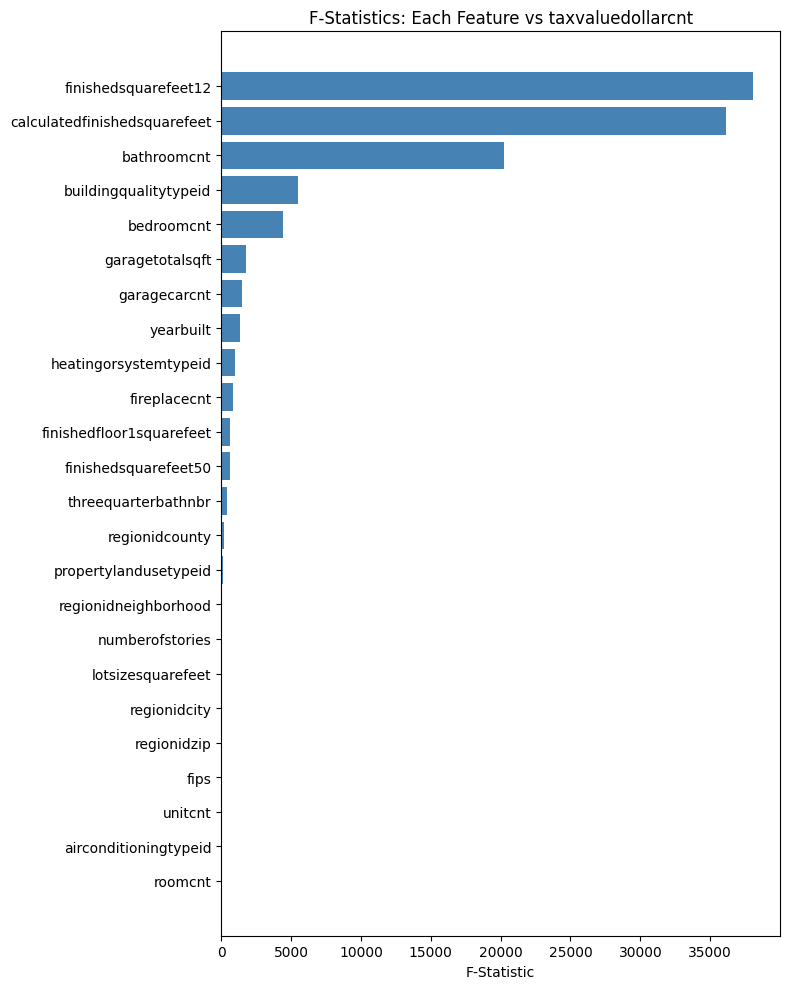

In [53]:
fstat_sorted = fstat_df.sort_values('f_stat', ascending=True)

plt.figure(figsize=(8, 10))
plt.barh(fstat_sorted['feature'], fstat_sorted['f_stat'], color='steelblue')
plt.xlabel('F-Statistic')
plt.title('F-Statistics: Each Feature vs taxvaluedollarcnt')
plt.tight_layout()
plt.show()

In [54]:
corr_rank = target_corr.abs().rank(ascending=False).rename('corr_rank')
fstat_rank = fstat_df.set_index('feature')['f_stat'].rank(ascending=False).rename('fstat_rank')

comparison = pd.concat([corr_rank, fstat_rank], axis=1).dropna()
comparison['rank_diff'] = (comparison['corr_rank'] - comparison['fstat_rank']).abs()
comparison = comparison.sort_values('corr_rank')

print("Feature ranking comparison (lower rank = more important):")
print(comparison.to_string())

Feature ranking comparison (lower rank = more important):
                              corr_rank  fstat_rank  rank_diff
finishedsquarefeet12                1.0         1.0        0.0
calculatedfinishedsquarefeet        2.0         2.0        0.0
bathroomcnt                         3.0         3.0        0.0
buildingqualitytypeid               4.0         4.0        0.0
bedroomcnt                          5.0         5.0        0.0
garagetotalsqft                     6.0         6.0        0.0
garagecarcnt                        7.0         7.0        0.0
yearbuilt                           8.0         8.0        0.0
heatingorsystemtypeid               9.0         9.0        0.0
fireplacecnt                       10.0        10.0        0.0
finishedfloor1squarefeet           11.0        11.0        0.0
finishedsquarefeet50               12.0        12.0        0.0
threequarterbathnbr                13.0        13.0        0.0
regionidcounty                     14.0        14.0        0

In [59]:
encoded_numeric = df_encoded.select_dtypes(include='number')
X_sel = encoded_numeric.drop(columns=['taxvaluedollarcnt', 'poolcnt', 'assessmentyear'])
y_sel = encoded_numeric['taxvaluedollarcnt']

print(f"Shape for feature selection: {X_sel.shape}")
print(f"Features: {X_sel.columns.tolist()}")

Shape for feature selection: (77404, 26)
Features: ['airconditioningtypeid', 'bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'finishedsquarefeet50', 'fips', 'fireplacecnt', 'garagecarcnt', 'garagetotalsqft', 'heatingorsystemtypeid', 'lotsizesquarefeet', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt', 'threequarterbathnbr', 'unitcnt', 'yearbuilt', 'numberofstories']


In [60]:
from sklearn.linear_model import LinearRegression

sfs_forward = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=10,
    direction='forward',
    cv=5,
    n_jobs=-1
)
sfs_forward.fit(X_sel, y_sel)

forward_features = X_sel.columns[sfs_forward.get_support()].tolist()
print("Forward Selection — Top 10 features:")
print(forward_features)

Forward Selection — Top 10 features:
['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'regionidcounty', 'regionidneighborhood', 'roomcnt', 'yearbuilt', 'numberofstories']


In [61]:
sfs_backward = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=10,
    direction='backward',
    cv=5,
    n_jobs=-1
)
sfs_backward.fit(X_sel, y_sel)

backward_features = X_sel.columns[sfs_backward.get_support()].tolist()
print("Backward Selection — Top 10 features:")
print(backward_features)

Backward Selection — Top 10 features:
['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'regionidcounty', 'regionidneighborhood', 'roomcnt', 'yearbuilt', 'numberofstories']


#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



The correlation analysis and F-statistic rankings agree completely, with every feature having a rank difference of 0.0, meaning both methods rank features identically. The two strongest predictors are finishedsquarefeet12 (r = 0.574) and calculatedfinishedsquarefeet (r = 0.564), confirming that interior living space is the dominant driver of assessed tax value. bathroomcnt (r = 0.455) is the next strongest, followed by buildingqualitytypeid and bedroomcnt with moderate correlations. Most other features fall below r = 0.15, suggesting weak linear relationships with the target. The negatively correlated features are primarily location ID and code columns whose negative values likely reflect arbitrary code numbering rather than a true inverse relationship. Both forward and backward sequential selection converged on the exact same 10 features, which strongly reinforces the validity of that feature set. Notably, garagetotalsqft and garagecarcnt ranked well in correlation but were excluded by both selection methods, suggesting their information is already captured by the square footage features, which is a sign of multicollinearity worth watching in modeling.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

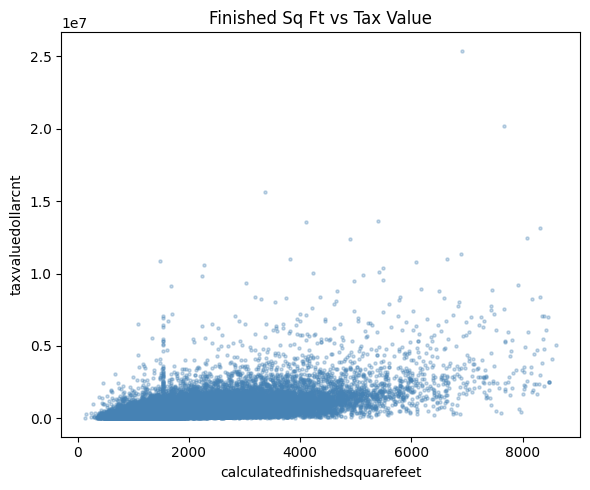

In [62]:
plt.figure(figsize=(6, 5))
plt.scatter(
    df_imputed['calculatedfinishedsquarefeet'],
    df_imputed['taxvaluedollarcnt'],
    alpha=0.3, s=5, color='steelblue'
)
plt.title('Finished Sq Ft vs Tax Value')
plt.xlabel('calculatedfinishedsquarefeet')
plt.ylabel('taxvaluedollarcnt')
plt.tight_layout()
plt.show()

The scatter plot of calculatedfinishedsquarefeet vs taxvaluedollarcnt shows a positive trend where larger homes tend to have higher assessed values. However the vast majority of data is densely packed near the bottom left with a few extreme outliers reaching up to 25 million in tax value. The heavy skew and fan shaped spread suggest that a log transformation on both axes would help expose the underlying linear relationship more clearly for modeling.

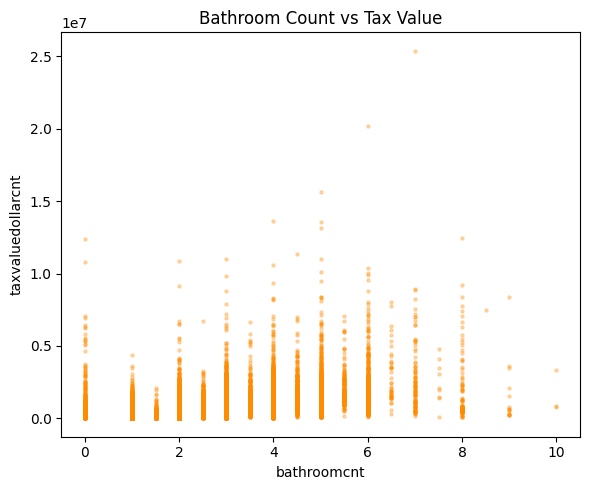

In [63]:
# Plot 2: bathroomcnt vs taxvaluedollarcnt
plt.figure(figsize=(6, 5))
plt.scatter(
    df_imputed['bathroomcnt'],
    df_imputed['taxvaluedollarcnt'],
    alpha=0.3, s=5, color='darkorange'
)
plt.title('Bathroom Count vs Tax Value')
plt.xlabel('bathroomcnt')
plt.ylabel('taxvaluedollarcnt')
plt.tight_layout()
plt.show()

The scatter plot of bathroomcnt vs taxvaluedollarcnt shows distinct vertical bands since bathroom count is a discrete variable, with most properties clustering between 0 and 6 bathrooms. Tax value does rise with bathroom count overall, but the spread within each band is very wide and there are notable outliers at nearly every count level, meaning bathroom count alone explains very little of the variance in tax value.

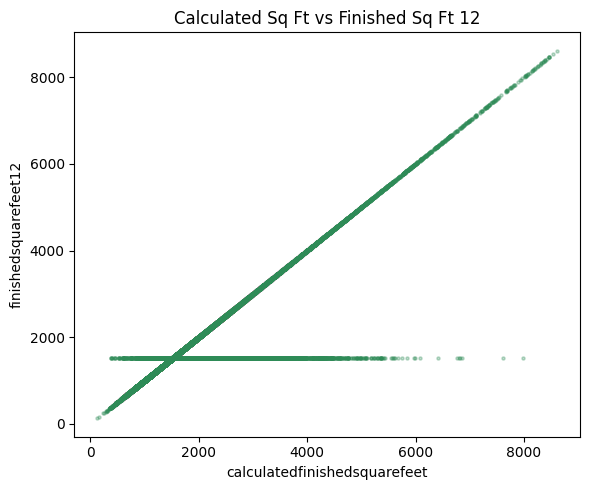

In [64]:
# Plot 3: calculatedfinishedsquarefeet vs finishedsquarefeet12
plt.figure(figsize=(6, 5))
plt.scatter(
    df_imputed['calculatedfinishedsquarefeet'],
    df_imputed['finishedsquarefeet12'],
    alpha=0.3, s=5, color='seagreen'
)
plt.title('Calculated Sq Ft vs Finished Sq Ft 12')
plt.xlabel('calculatedfinishedsquarefeet')
plt.ylabel('finishedsquarefeet12')
plt.tight_layout()
plt.show()

The scatter plot of calculatedfinishedsquarefeet vs finishedsquarefeet12 reveals an almost perfectly diagonal line, confirming that these two features are nearly identical to each other. The horizontal band of points near y=1500 is particularly interesting and likely represents properties where finishedsquarefeet12 was imputed to the median value during the imputation step, which is further evidence that one of these two columns should be dropped before modeling to avoid redundancy.

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

